# Exercise 3: Neural networks in PyTorch

In this exercise you’ll implement small neural-network building blocks from scratch and use them to train a simple classifier.

You’ll cover:
- **Basic layers**: Linear, Embedding, Dropout
- **Normalization**: LayerNorm and RMSNorm
- **MLPs + residual**: composing layers into deeper networks
- **Classification**: generating a learnable dataset, implementing cross-entropy from logits, and writing a minimal training loop

As before: fill in all `TODO`s without changing function names or signatures.
Use small sanity checks and compare to PyTorch reference implementations when useful.

In [61]:
from __future__ import annotations

import torch
from torch import nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu" )

## Basic layers

In this section you’ll implement a few core layers that appear everywhere:

### `Linear`
A fully-connected layer that follows nn.Linear conventions:  
`y = x @ Wᵀ + b`

Important details:
- Parameters should be registered as `nn.Parameter`
- Store weight as (out_features, in_features) like nn.Linear.
- The forward pass should support leading batch dimensions: `x` can be shape `(..., in_features)`

### `Embedding`
An embedding table maps integer ids to vectors:
- input: token ids `idx` of shape `(...,)`
- output: vectors of shape `(..., embedding_dim)`

This is essentially a learnable lookup table.

### `Dropout`
Dropout randomly zeroes activations during training to reduce overfitting.
Implementation details:
- Only active in `model.train()` mode
- In training: drop with probability `p` and scale the kept values by `1/(1-p)` so the expected value stays the same
- In eval: return the input unchanged

## Instructions
- Do not use PyTorch reference modules for the parts you implement (e.g. don’t call nn.Linear inside your Linear).
- You may use standard tensor ops that you learned before (matmul, sum, mean, rsqrt, indexing, etc.).
- Use a parameter initialization method of your choice. We recommend something like Xavier-uniform.


In [62]:
class Linear(nn.Module):
    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        # TODO: initialize parameters
        weight = torch.nn.init.xavier_uniform_(torch.empty(size=(out_features,in_features)))
        self.weight = torch.nn.Parameter(data=weight)
        if bias:
            bias = torch.zeros(out_features)
            self.bias = torch.nn.Parameter(data=bias)
        else:
            self.bias = None
            
            

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., in_features)
        return: (..., out_features)
        """
        # TODO: implement
        return x @ self.weight.T + self.bias

In [63]:
class Embedding(nn.Module):
    def __init__(self, num_embeddings: int, embedding_dim: int):
        super().__init__()
        # TODO: initialize
        weight = torch.nn.init.xavier_uniform_(torch.empty(size=(num_embeddings,embedding_dim)))
        self.weight = torch.nn.Parameter(data=weight)
    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        """
        idx: (...,) int64
        return: (..., embedding_dim)
        """
        # TODO: implement (index into weight)
        return self.weight[idx]

In [64]:
class Dropout(nn.Module):
    def __init__(self, p: float):
        super().__init__()

        assert(0 <= p <= 1)

        self.dropout = p

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        In train mode: drop with prob p and scale by 1/(1-p).
        In eval mode: return x unchanged.
        """
        # TODO: implement without using nn.Dropout

        if self.training: # is in train mode?
            mask = torch.rand_like(x) >= self.dropout
            return x * mask / (1 - self.dropout + 1e-6) # avoid division by zero
        else:
            return x
        

drop = Dropout(p=1.0)
x = torch.rand(size=(3,3))
print(drop(x))

drop = Dropout(p=0.2)
x = torch.rand(size=(4,4))
print(drop(x))

drop = Dropout(p=0.5)
x = torch.rand(size=(10,10))
print(drop(x))
        

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
tensor([[0.0000, 1.0580, 0.1051, 1.0650],
        [0.4905, 0.8763, 0.0000, 0.6724],
        [0.9222, 0.7203, 0.8886, 0.3863],
        [0.2426, 0.0000, 0.0710, 0.4438]])
tensor([[0.5758, 0.0000, 0.0000, 0.0000, 0.0000, 1.9537, 0.0000, 1.3184, 1.7022,
         0.0000],
        [1.3239, 0.0000, 0.0000, 0.0000, 1.4350, 0.0000, 0.0000, 1.5973, 0.5549,
         0.0000],
        [0.0000, 0.0000, 1.9370, 0.0000, 0.6228, 0.1853, 0.0000, 0.1123, 0.2712,
         1.9107],
        [0.0000, 0.2904, 0.5688, 1.6778, 0.0000, 1.7172, 0.4278, 1.7480, 0.0000,
         0.0000],
        [0.0395, 0.0496, 1.6824, 1.6164, 0.0000, 0.0932, 0.0000, 0.0000, 0.0000,
         0.0000],
        [1.7386, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 1.8942,
         0.0000],
        [0.6289, 1.4205, 1.0543, 0.0000, 1.7370, 1.1980, 0.4137, 0.0000, 0.0000,
         0.4621],
        [0.9208, 0.0000, 0.0000, 0.7156, 0.0000, 0.0000, 0.7630, 0.0000

## Normalization

Normalization layers help stabilize training by controlling activation statistics.

### LayerNorm
LayerNorm normalizes each example across its **feature dimension** (the last dimension):

- compute mean and variance over the last dimension
- normalize: `(x - mean) / sqrt(var + eps)`
- apply learnable per-feature scale and shift (`weight`, `bias`)

**In this exercise, assume `elementwise_affine=True` (always include `weight` and `bias`).**  
`weight` and `bias` each have shape `(D,)`.

LayerNorm is widely used in transformers because it does not depend on batch statistics.

### RMSNorm
RMSNorm is similar to LayerNorm but normalizes using only the root-mean-square:
- `x / sqrt(mean(x^2) + eps)` over the last dimension
- usually includes a learnable scale (`weight`)
- no mean subtraction

RMSNorm is popular in modern LLMs because it's faster.


In [65]:
class LayerNorm(nn.Module):
    def __init__(
        self, normalized_shape: int, eps: float = 1e-5, elementwise_affine: bool = True
    ):
        super().__init__()
        # TODO: implement
        self.weight = torch.nn.Parameter(torch.ones(normalized_shape))
        self.bias = torch.nn.Parameter(torch.zeros(normalized_shape))
        self.eps = eps
        self.elementwise_affine = elementwise_affine

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Normalize over the last dimension.
        x: (..., D)
        """
        # TODO: implement
        mean = torch.mean(x, dim=-1, keepdim=True)
        var = torch.var(x, dim=-1, keepdim=True,correction=0)
        x_hat = (x - mean) / torch.sqrt(var + self.eps)
        if self.elementwise_affine:
            return self.weight * x_hat + self.bias
        else:
            return x_hat
    

B = 10
D = 4
x = torch.rand(size=(B,D))

ln_mine = LayerNorm(D)
ln_torch = torch.nn.LayerNorm(D)

print(f"My implementation: {ln_mine(x)} \n\n Pytorch's Implementation: {ln_torch(x)}")


My implementation: tensor([[ 0.4581,  0.5013,  0.7609, -1.7203],
        [-0.6603,  0.5317, -1.2149,  1.3435],
        [ 0.6064,  0.2010, -1.6814,  0.8741],
        [ 1.4334,  0.2407, -0.3443, -1.3298],
        [ 0.5219,  1.0662, -1.6093,  0.0212],
        [-0.3367, -0.5939,  1.7104, -0.7798],
        [-0.8786,  0.4293,  1.4376, -0.9882],
        [-0.2985,  1.5356, -1.2459,  0.0088],
        [-0.6901,  0.9373, -1.2669,  1.0197],
        [ 1.1465, -0.9221,  0.8390, -1.0634]], grad_fn=<AddBackward0>) 

 Pytorch's Implementation: tensor([[ 0.4581,  0.5013,  0.7609, -1.7203],
        [-0.6603,  0.5317, -1.2149,  1.3435],
        [ 0.6064,  0.2010, -1.6814,  0.8741],
        [ 1.4334,  0.2407, -0.3443, -1.3298],
        [ 0.5219,  1.0662, -1.6093,  0.0212],
        [-0.3367, -0.5939,  1.7104, -0.7798],
        [-0.8786,  0.4293,  1.4376, -0.9882],
        [-0.2985,  1.5356, -1.2459,  0.0088],
        [-0.6901,  0.9373, -1.2669,  1.0197],
        [ 1.1465, -0.9221,  0.8390, -1.0634]],
      

In [66]:
class RMSNorm(nn.Module):
    def __init__(self, normalized_shape: int, eps: float = 1e-8):
        super().__init__()
        # TODO: implement
        self.weight = torch.nn.Parameter(torch.ones(normalized_shape))
        self.eps = eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        RMSNorm: x / sqrt(mean(x^2) + eps) * weight
        over the last dimension.
        """
        # TODO: implement
        return x / (torch.sqrt(torch.mean(x ** 2, dim=-1, keepdim=True) + self.eps)) * self.weight
    

B = 10
D = 4
x = torch.rand(size=(B,D))

rms_mine = RMSNorm(D)
rms_torch = torch.nn.RMSNorm(D)

print(f"My implementation: {rms_mine(x)} \n\n Pytorch's Implementation: {rms_torch(x)}")

My implementation: tensor([[1.5055, 0.2543, 0.5341, 1.1762],
        [0.6626, 1.7534, 0.3310, 0.6140],
        [1.0322, 0.9023, 0.8143, 1.2072],
        [0.9636, 0.7857, 1.0342, 1.1767],
        [0.8348, 1.0538, 0.0248, 1.4805],
        [0.0292, 0.5363, 1.5473, 1.1477],
        [0.3967, 1.1965, 1.2635, 0.9025],
        [1.3405, 0.7736, 1.1971, 0.4142],
        [0.7688, 1.0769, 0.9209, 1.1837],
        [1.0708, 1.5277, 0.5674, 0.4445]], grad_fn=<MulBackward0>) 

 Pytorch's Implementation: tensor([[1.5055, 0.2543, 0.5341, 1.1762],
        [0.6626, 1.7534, 0.3310, 0.6140],
        [1.0322, 0.9023, 0.8143, 1.2072],
        [0.9636, 0.7856, 1.0342, 1.1767],
        [0.8348, 1.0538, 0.0248, 1.4805],
        [0.0292, 0.5363, 1.5473, 1.1477],
        [0.3967, 1.1965, 1.2635, 0.9025],
        [1.3405, 0.7736, 1.1971, 0.4142],
        [0.7688, 1.0769, 0.9209, 1.1837],
        [1.0708, 1.5277, 0.5674, 0.4445]], grad_fn=<MulBackward0>)


## MLPs and residual networks

Now you’ll build larger networks by composing layers.

### MLP
An MLP is a stack of `depth` Linear layers with non-linear activations (use GELU) in between.
In this exercise you’ll support:
- configurable depth
- a hidden dimension
- optional LayerNorm between layers (a common stabilization trick)

A key skill is building networks using `nn.ModuleList` / `nn.Sequential` while keeping shapes consistent.

### Transformer-style FeedForward (FFN)
A transformer block contains a position-wise feedforward network:
- `D -> 4D -> D` (by default)
- activation is typically **GELU**

This is essentially an MLP applied independently at each token position.

### Residual wrapper
Residual connections are the simplest form of “skip connection”:
- output is `x + fn(x)`

They improve gradient flow and allow training deeper networks more reliably.

In [67]:
class MLP(nn.Module):
    def __init__(
        self,
        in_dim: int,
        hidden_dim: int,
        out_dim: int,
        depth: int,
        use_layernorm: bool = False,
    ):
        super().__init__()
        # TODO: build modules (list of Linear + activation)
        # Optionally insert LayerNorm between layers.
        curr_dim = in_dim
        dims = [hidden_dim] * (depth - 1) + [out_dim]
        layers = nn.ModuleList()

        for dim in dims:

            if dim == out_dim:
                layers.append(nn.Linear(curr_dim, dim))
                continue
            
            layers.append(nn.Linear(curr_dim,dim))
            layers.append(nn.GELU())

            if use_layernorm:
                layers.append(LayerNorm(dim))

            curr_dim = dim
        
        self.mlp = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: implement
        return self.mlp(x)
    
model = MLP(in_dim=3, hidden_dim=6, out_dim=1, depth=3, use_layernorm=True)
print(model)

model = MLP(in_dim=3, hidden_dim=6, out_dim=1, depth=1, use_layernorm=True)
print(model)

model = MLP(in_dim=3, hidden_dim=6, out_dim=1, depth=4, use_layernorm=False)
print(model)


MLP(
  (mlp): Sequential(
    (0): Linear(in_features=3, out_features=6, bias=True)
    (1): GELU(approximate='none')
    (2): LayerNorm()
    (3): Linear(in_features=6, out_features=6, bias=True)
    (4): GELU(approximate='none')
    (5): LayerNorm()
    (6): Linear(in_features=6, out_features=1, bias=True)
  )
)
MLP(
  (mlp): Sequential(
    (0): Linear(in_features=3, out_features=1, bias=True)
  )
)
MLP(
  (mlp): Sequential(
    (0): Linear(in_features=3, out_features=6, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=6, out_features=6, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=6, out_features=6, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=6, out_features=1, bias=True)
  )
)


In [68]:
class FeedForward(nn.Module):
    """
    Transformer-style FFN: D -> 4D -> D (default)
    """

    def __init__(self, d_model: int, d_ff: int | None = None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        # TODO: create two Linear layers and choose an activation (GELU)
        self.ffn = nn.Sequential(
            nn.Linear(d_model,d_ff),
            nn.GELU(),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: implement
        return self.ffn(x)

In [69]:
class Residual(nn.Module):
    def __init__(self, fn: nn.Module):
        super().__init__()
        # TODO: implement
        self.fn = fn

    def forward(self, x: torch.Tensor, *args, **kwargs) -> torch.Tensor:
        # TODO: return x + fn(x, ...)
        return x + self.fn(x,*args,**kwargs)

## Classification problem

In this section you’ll put everything together in a minimal MNIST classification experiment.

You will:
1) download and load the MNIST dataset
2) implement cross-entropy from logits (stable, using log-softmax)
3) build a simple MLP-based classifier (flatten MNIST images first)
4) write a minimal training loop
5) report train loss curve and final accuracy

The goal here is not to reach state-of-the-art accuracy, but to understand the full pipeline:
data → model → logits → loss → gradients → parameter update.

### Model notes
- We want you to combine the MLP we implemented above with the classification head we define below into one model 

### MNIST notes
- MNIST images are `28×28` grayscale.
- After `ToTensor()`, each image has shape `(1, 28, 28)` and values in `[0, 1]`.
- For an MLP classifier, we flatten to a vector of length `784`.

## Deliverables
- Include a plot of your train loss curve in the video submission as well as a final accuracy. 
- **NOTE** Here we don't grade on model performance but we expect you to achieve at least 70% accuracy to confirm a correct model implementation.

In [70]:
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [91]:
transform = transforms.ToTensor()  # -> float32 in [0,1], shape (1, 28, 28)

train_ds = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

# TODO: define the dataloaders
batch = 128
train_loader = DataLoader(dataset=train_ds, batch_size=batch, shuffle=True,num_workers=0)
test_loader = DataLoader(dataset=test_ds, batch_size=2 * batch, shuffle=False,num_workers=0)

In [77]:
def cross_entropy_from_logits(
    logits: torch.Tensor,
    targets: torch.Tensor,
) -> torch.Tensor:
    """
    Compute mean cross-entropy loss from logits.

    logits: (B, C)
    targets: (B,) int64

    Requirements:
    - Use log-softmax for stability (do not use torch.nn.CrossEntropyLoss, we check this in the autograder).
    """
    # TODO: implement
    # log-softmax implementation
    logits_max = torch.max(logits, dim=1, keepdim=True)[0]
    log_softmax = logits - logits_max - torch.log(torch.sum(torch.exp(logits - logits_max)))
    rows = torch.arange(start=0, end=log_softmax.size(0),step=1)
    probabilities = - log_softmax[rows,targets]
    return probabilities.mean()

In [78]:
class ClassificationHead(nn.Module):
    def __init__(self, d_in: int, num_classes: int):
        super().__init__()
        # TODO: implement
        self.linear = nn.Linear(d_in, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        x: (..., d_in)
        return: (..., num_classes) logits
        """
        # TODO: implement
        return self.linear(x)

In [85]:
def accuracy(loader):
    # TODO: You can use this function to evaluate your model accuracy.
    correct = 0.0
    total = 0.0
    model.eval()
    with torch.no_grad():
        for x,y in loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            total += x.shape[0]

            logits = model(x.flatten(1,-1))
            pred = torch.argmax(logits, dim=-1)
            correct += (pred==y).sum().item()
    
    accuracy = correct / total
    print(f"Model's accuracy is: {accuracy}")


In [92]:
def train_classifier(
    model: nn.Module,
    train_data_loader: DataLoader,
    test_data_loader: DataLoader,
    lr: float,
    epochs: int,
    seed: int = 0,
) -> list[float]:
    """
    Minimal training loop for MNIST classification.

    Steps:
    - define optimizer
    - for each epoch:
        - sample minibatches
        - forward -> cross-entropy -> backward -> optimizer step
      - compute test accuracy at the end of each epoch
    - return list of training losses (one per update step)

    Requirements:
    - call model.train() during training and model.eval() during evaluation
    - do not use torch.nn.CrossEntropyLoss (use your cross_entropy_from_logits)
    """
    # TODO: implement
    torch.manual_seed(seed)
    losses = []
    optimizer = torch.optim.AdamW(params=model.parameters(), lr=lr)
    model.train()

    for i in range(epochs):
        #  --- TRAINING ---
        for x,y in train_data_loader:
            x = x.to(DEVICE)
            y = y.to(DEVICE)

            optimizer.zero_grad()
            logits = model(x.flatten(1,-1))
            loss = cross_entropy_from_logits(logits, y)
            
            # --- Optimization ---
            loss.backward()
            optimizer.step()
            losses.append(loss.item())

        print(f"Epoch: {i + 1} Training loss: {losses[i]}")
        accuracy(test_data_loader)
    
    return losses
    


In [101]:
model = nn.Sequential(MLP(784,256,64,3), ClassificationHead(64,10)).to(DEVICE)

lr = 3e-3
epochs = 10

losses = train_classifier(model, train_loader, test_loader, lr, epochs)

Epoch: 1 Training loss: 7.156826972961426
Model's accuracy is: 0.965
Epoch: 2 Training loss: 7.108939170837402
Model's accuracy is: 0.9692
Epoch: 3 Training loss: 7.007174491882324
Model's accuracy is: 0.9756
Epoch: 4 Training loss: 6.825302600860596
Model's accuracy is: 0.9785
Epoch: 5 Training loss: 6.693676948547363
Model's accuracy is: 0.9721
Epoch: 6 Training loss: 6.433553695678711
Model's accuracy is: 0.9756
Epoch: 7 Training loss: 6.229313850402832
Model's accuracy is: 0.9791
Epoch: 8 Training loss: 6.053686141967773
Model's accuracy is: 0.9768
Epoch: 9 Training loss: 6.020782470703125
Model's accuracy is: 0.9771
Epoch: 10 Training loss: 5.667988300323486
Model's accuracy is: 0.9778


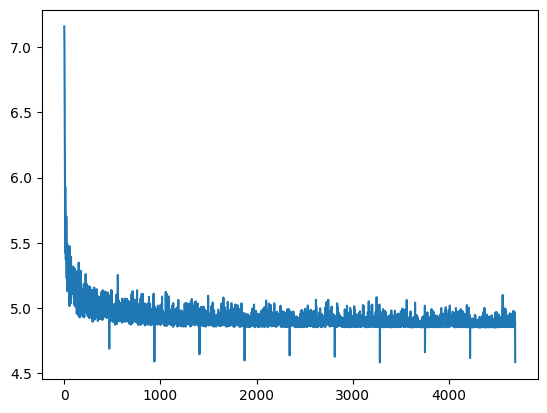

In [102]:
# --- Curve Plot --- #
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, len(losses)-1, len(losses), dtype=int)

y = np.array(losses)[x]

fig, ax = plt.subplots()
ax.plot(x,y)
plt.show()
